In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import torch
import torch.nn as nn
from dataclasses import dataclass
from nltk import tokenize
import random
import numpy as np
import spacy
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

In [45]:
nltk.download('punkt_tab')
nltk.download('stopwords')

nlp = spacy.load('ro_core_news_sm')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/denis2104/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/denis2104/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [46]:
@dataclass
class CFG:
    train_file_path: str = 'train_sentiment_analysis.csv'
    test_file_path: str = 'test_sentiment_analysis.csv'
    batch_size: int = 32
    device: str = 'mps' if torch.backends.mps.is_available() else 'cpu'
    num_epochs: int = 20
    early_stopping_steps: int = 4
    criterion: nn.Module = nn.CrossEntropyLoss(label_smoothing=0.1) 
    learning_rate: float = 0.0001  
    weight_decay: float = 5e-4
    embedding_dim: int = 300
    hidden_dim: int = 64
    output_dim: int = 2
    n_layers: int = 1
    dropout: float = 0.6
    embedding_dropout: float = 0.3
    max_len: int = 200
    fasttext_path: str = 'cc.ro.300.vec'
    use_augmentation: bool = True 
    max_grad_norm: float = 1.0

In [47]:
def load_csv(file_path):
    dataframe = pd.read_csv(file_path,skiprows=1, names=['index', 'text', 'label'])
    return dataframe

def open_test_and_train_csv():
    return load_csv(CFG.test_file_path), load_csv(CFG.train_file_path)

test, train = open_test_and_train_csv()

In [48]:
def check_for_empty_values(dataset):
    empty_values = dataset[dataset['text'].isnull() | (dataset['text'].str.strip() == '')]
    return empty_values

empty_values_train = check_for_empty_values(train)
print(f"Empty values in Train Dataset: {len(empty_values_train)}")
if not empty_values_train.empty:
    train = train.drop(empty_values_train.index)
    
empty_values_test = check_for_empty_values(test)
print(f"Empty values in Test Dataset: {len(empty_values_test)}")
if not empty_values_test.empty:
    test = test.drop(empty_values_test.index)

Empty values in Train Dataset: 290
Empty values in Test Dataset: 0


In [49]:
def data_leakage_text(train_dataset, test_dataset):
    train_texts = set(train_dataset['text'])
    test_texts = set(test_dataset['text'])
    overlapping_texts = train_texts.intersection(test_texts)
    print(f"Number of overlapping texts between Train and Test datasets: {len(overlapping_texts)}")
    return overlapping_texts

def discard_data_leakage_examples_from_test(list_of_text_to_remove, test_dataset):
    indexes_to_remove = test_dataset[test_dataset['text'].isin(list_of_text_to_remove)].index
    test_dataset.drop(indexes_to_remove, inplace=True)

discard_data_leakage_examples_from_test(data_leakage_text(train, test), test)

Number of overlapping texts between Train and Test datasets: 56


In [50]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

def make_a_clean_text(dataset):
    dataset['clean_text_for_duplicates'] = dataset['text'].apply(clean_text)

make_a_clean_text(train)
make_a_clean_text(test)

In [51]:
def check_for_duplicate_values(dataset):
    duplicate_values = dataset[dataset.duplicated(subset=['clean_text_for_duplicates'], keep=False)]
    return duplicate_values

duplicate_text_in_train = check_for_duplicate_values(train)
duplicate_text_in_test = check_for_duplicate_values(test)

print(f"Duplicate values in Train Dataset: {len(duplicate_text_in_train)}")
print(f"Duplicate values in Test Dataset: {len(duplicate_text_in_test)}")

Duplicate values in Train Dataset: 1923
Duplicate values in Test Dataset: 322


In [52]:
def see_positive_negative_sentiments_per_duplicate_text(duplicate_dataset):
    text_with_positive_and_negative_counts = []
    grouped = duplicate_dataset.groupby('clean_text_for_duplicates')
    for name, group in grouped:
        positive_count = len(group[group['label'] == 1])
        negative_count = len(group[group['label'] == 0])
        text_with_positive_and_negative_counts.append((name, (positive_count, negative_count)))
        
    return text_with_positive_and_negative_counts

In [53]:
def see_dominant_sentiment_per_duplicate_text(list_of_duplicated_text):
    for text, (positive_count, negative_count) in list_of_duplicated_text:
        if positive_count != negative_count and positive_count > 0 and negative_count > 0:
            print(f"Text: {text}\n (Positive: {positive_count}, Negative: {negative_count})\n")

see_dominant_sentiment_per_duplicate_text(see_positive_negative_sentiments_per_duplicate_text(duplicate_text_in_train))
see_dominant_sentiment_per_duplicate_text(see_positive_negative_sentiments_per_duplicate_text(duplicate_text_in_test))

Text: 
 (Positive: 3, Negative: 1)



In [54]:
def drop_duplicate_values(dataset):
    dataset.drop_duplicates(subset=['clean_text_for_duplicates'], keep='first', inplace=True)

drop_duplicate_values(train)
drop_duplicate_values(test)

In [55]:
def lead_trailing_dot_punctuation_removal(text):
    return re.findall(r'([!?.,:;\'"()-]{2,})(?=\s|$)', text)

def see_pattern_of_punctuation_marks_in_text(dataset):  
    list_of_patterns_in_train = [lead_trailing_dot_punctuation_removal(text) for text in dataset['text']] 
    return Counter([item for sublist in list_of_patterns_in_train if sublist for item in sublist])

patterns_of_punctuation_in_train = see_pattern_of_punctuation_marks_in_text(train)
patterns_of_punctuation_in_test = see_pattern_of_punctuation_marks_in_text(test)

print(f"Patterns of punctuation marks in Train Dataset: {patterns_of_punctuation_in_train.most_common(80)}")
print(f"Patterns of punctuation marks in Test Dataset: {patterns_of_punctuation_in_test.most_common(80)}")

Patterns of punctuation marks in Train Dataset: [('...', 3877), ('".', 1287), (').', 1267), ('",', 1169), ('),', 1045), ('..', 746), ('!!!', 397), ('....', 392), (':)', 268), ('!!', 247), ('.....', 159), ('.)', 132), ('!"', 118), ('!)', 118), ('!!!!', 118), (':))', 118), ('?"', 86), ('.,', 82), ('?)', 81), ('")', 75), (';)', 73), ('."', 68), ('???', 68), ('......', 63), ('!!!!!', 61), ('?!', 60), ('!).', 53), ('"),', 48), ('!),', 45), ("''", 42), ('"?', 40), ('").', 38), ('"!', 37), ('.......', 33), ('??', 33), (':(', 30), ('!!!!!!', 29), ('?),', 29), ('::', 28), (');', 26), ('...)', 26), ('..."', 24), ('";', 23), ('?).', 23), (',,', 23), (':-)', 22), ("'.", 21), ('):', 21), ('!!!!!!!', 21), ('.........', 20), ('!!!!!!!!', 17), (':).', 17), ('---', 17), ('........', 16), ('?".', 16), ('"...', 15), (')!', 15), ('!.', 14), ("',", 13), ('.),', 13), ('))', 13), ('(!)', 13), ('????', 13), ('.).', 12), (')))', 12), (';))', 12), (')?', 12), ('...,', 12), (')...', 11), ('":', 11), ('...).', 10

In [56]:
def clean_trailing_punctuation(text):
    if not isinstance(text, str):
        return text
    
    text = text.rstrip()
    match = re.search(r'([.?!]+)$', text)
    
    if match:
        punct_group = match.group(1)
        if len(punct_group) > 1:
            counts = Counter(punct_group)
            
            dominant_punct = counts.most_common(1)[0][0]
            
            return text[:match.start()] + dominant_punct
            
    return text

def apply_trailing_punctuation_cleaning(dataset):
    dataset['text'] = dataset['text'].apply(clean_trailing_punctuation)

apply_trailing_punctuation_cleaning(train)
apply_trailing_punctuation_cleaning(test)

In [57]:
def lemmatize_and_filter_names(text):
    if not isinstance(text, str): 
        return ""
    
    doc = nlp(text.lower())
    
    clean_lemmas = []
    for token in doc:
        if not token.is_stop and not token.is_punct and not token.is_space:
            if token.pos_ != "PROPN":
                clean_lemmas.append(token.lemma_)
    
    return " ".join(clean_lemmas)

train['text'] = train['text'].apply(lemmatize_and_filter_names)
test['text'] = test['text'].apply(lemmatize_and_filter_names)

In [58]:
def see_positive_and_negative_for_a_dataset(dataset):
    positive_count = len(dataset[dataset['label'] == 1])
    negative_count = len(dataset[dataset['label'] == 0])
    return positive_count, negative_count

In [59]:
def plot_count_plot(values,type_of_element='label', title='Count Plot'):
    plt.figure(figsize=(8,6))
    plt.title(title)
    plt.xlabel(type_of_element)
    plt.ylabel('Count')
    elements = ['Test', 'Train']
    plt.bar(elements, values, color=['blue', 'orange'])
    plt.show()

In [60]:
def plot_positive_vs_negative_for_a_dataset(dataset, type_of_data = 'Train'):
    positive, negative = see_positive_and_negative_for_a_dataset(dataset)
    labels = ['Positive', 'Negative']
    sizes = [positive, negative]
    plt.figure(figsize=(6,6))
    plt.bar(labels, sizes, color=['green', 'red'])
    plt.title('Positive vs Negative Sentiments on ' + type_of_data + ' Dataset')
    plt.show()

In [61]:
positive_train, negative_train = see_positive_and_negative_for_a_dataset(train)
positive_test, negative_test = see_positive_and_negative_for_a_dataset(test)

print(f"Train Dataset: Positive samples = {positive_train}, Negative samples = {negative_train}")
print(f"Test Dataset: Positive samples = {positive_test}, Negative samples = {negative_test}")

print(f"Ratio of Positive to Negative in Train Dataset: {positive_train / negative_train:.2f}")
print(f"Ratio of Positive to Negative in Test Dataset: {positive_test / negative_test:.2f}")

Train Dataset: Positive samples = 9934, Negative samples = 6536
Test Dataset: Positive samples = 6057, Negative samples = 4729
Ratio of Positive to Negative in Train Dataset: 1.52
Ratio of Positive to Negative in Test Dataset: 1.28


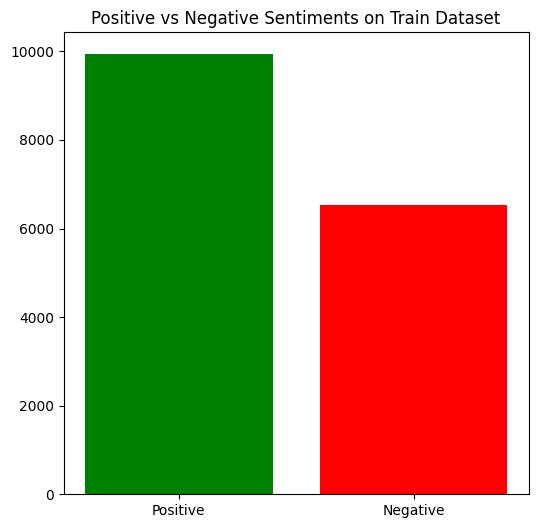

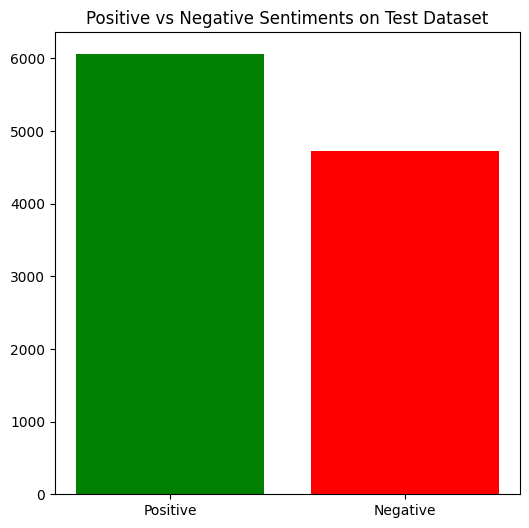

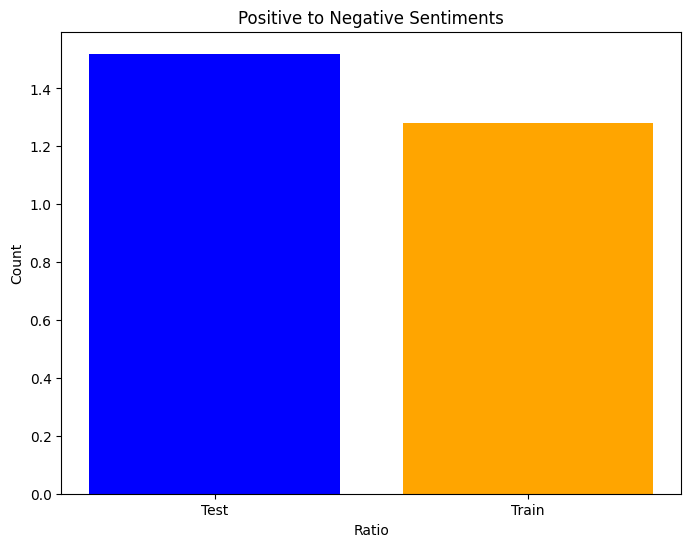

In [62]:
plot_positive_vs_negative_for_a_dataset(train, type_of_data='Train')
plot_positive_vs_negative_for_a_dataset(test, type_of_data='Test')
plot_count_plot([positive_train / negative_train, positive_test / negative_test], type_of_element='Ratio', title='Positive to Negative Sentiments')

In [63]:
def make_length_column_for_dataset(dataset):
    dataset['length'] = dataset['text'].str.len()

def make_word_count_column_for_dataset(dataset):
    dataset['word_count'] = dataset['text'].str.split().apply(len)

def make_mean_word_length_column_for_dataset(dataset):
    dataset['mean_word_length'] = dataset['text'].apply(lambda x: sum(len(word) for word in x.split()) / len(x.split()) if len(x.split()) > 0 else 0)

def make_mean_sentence_length_column_for_dataset(dataset):
    dataset['mean_sentence_length'] = dataset['text'].apply(lambda x: sum(len(sentence) for sentence in tokenize.sent_tokenize(x)) / len(tokenize.sent_tokenize(x)) if len(tokenize.sent_tokenize(x)) > 0 else 0)

In [64]:
make_length_column_for_dataset(train)
make_word_count_column_for_dataset(train)
make_mean_word_length_column_for_dataset(train)
make_mean_sentence_length_column_for_dataset(train)

make_length_column_for_dataset(test)
make_word_count_column_for_dataset(test)
make_mean_word_length_column_for_dataset(test)
make_mean_sentence_length_column_for_dataset(test)

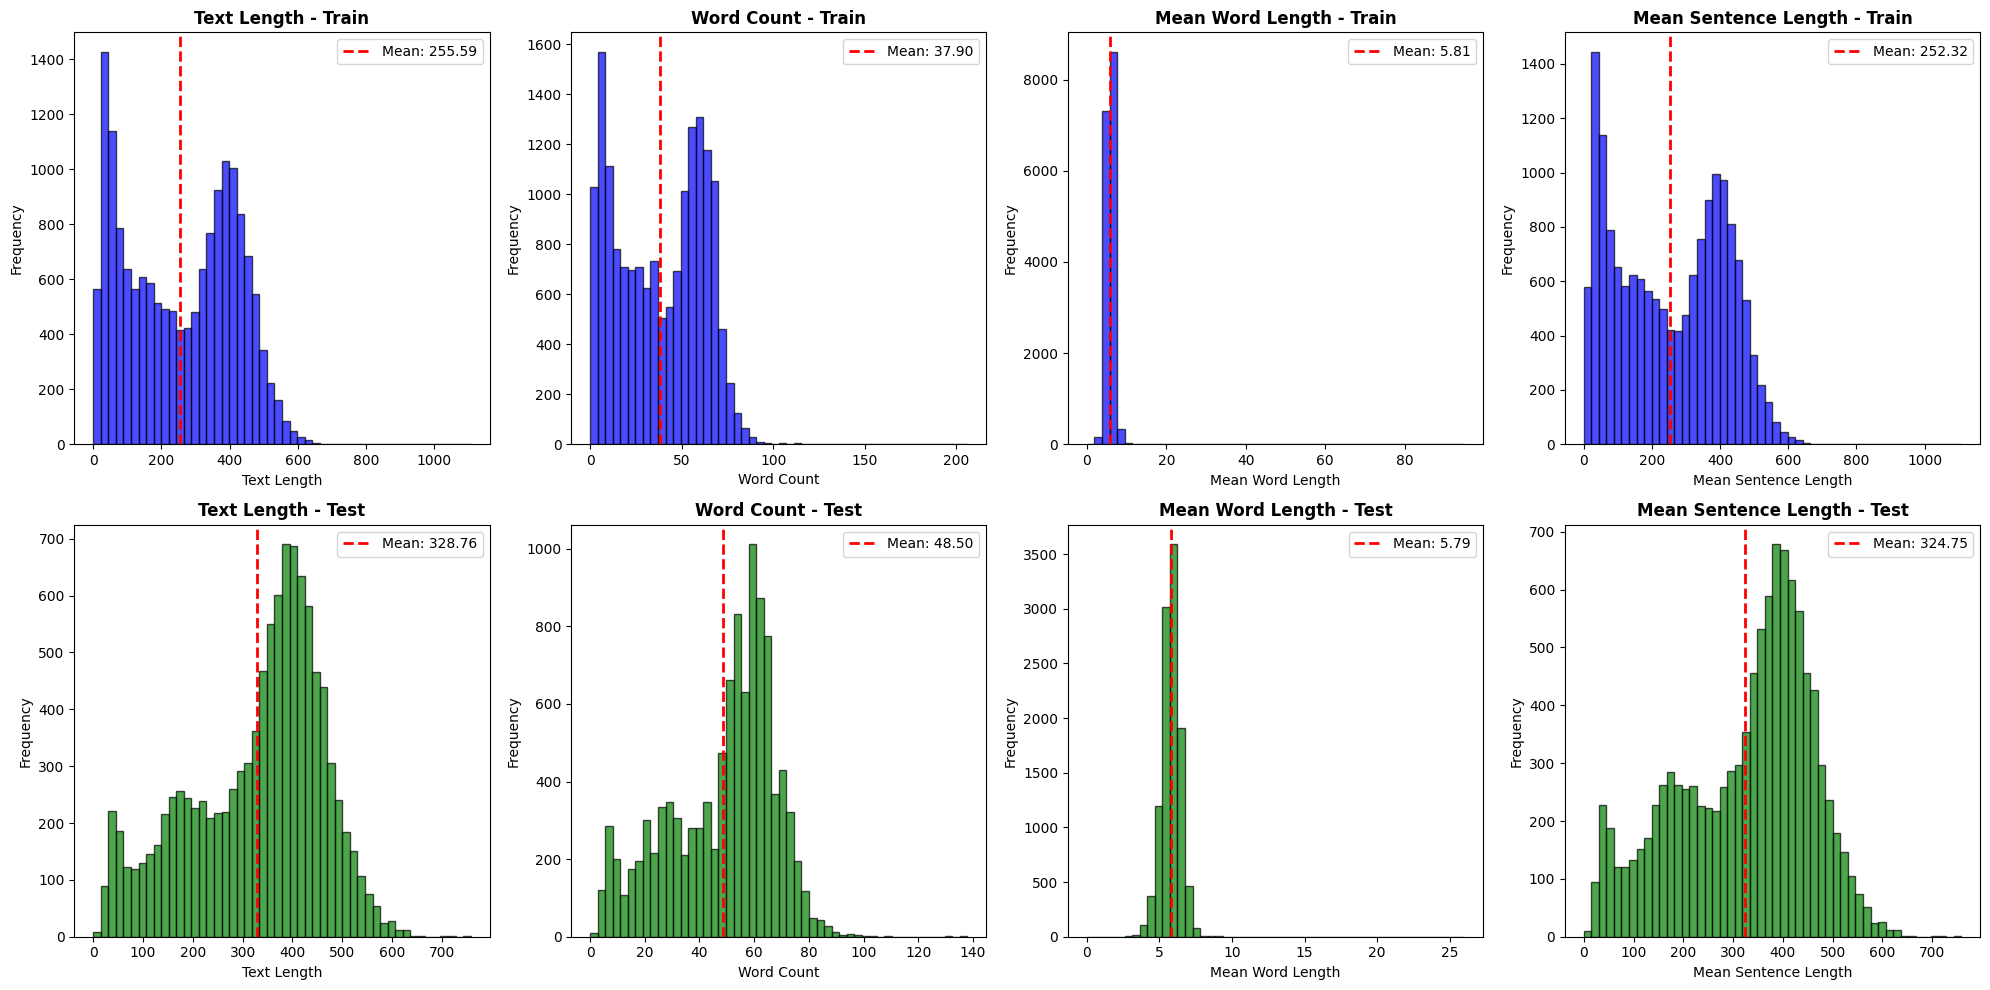

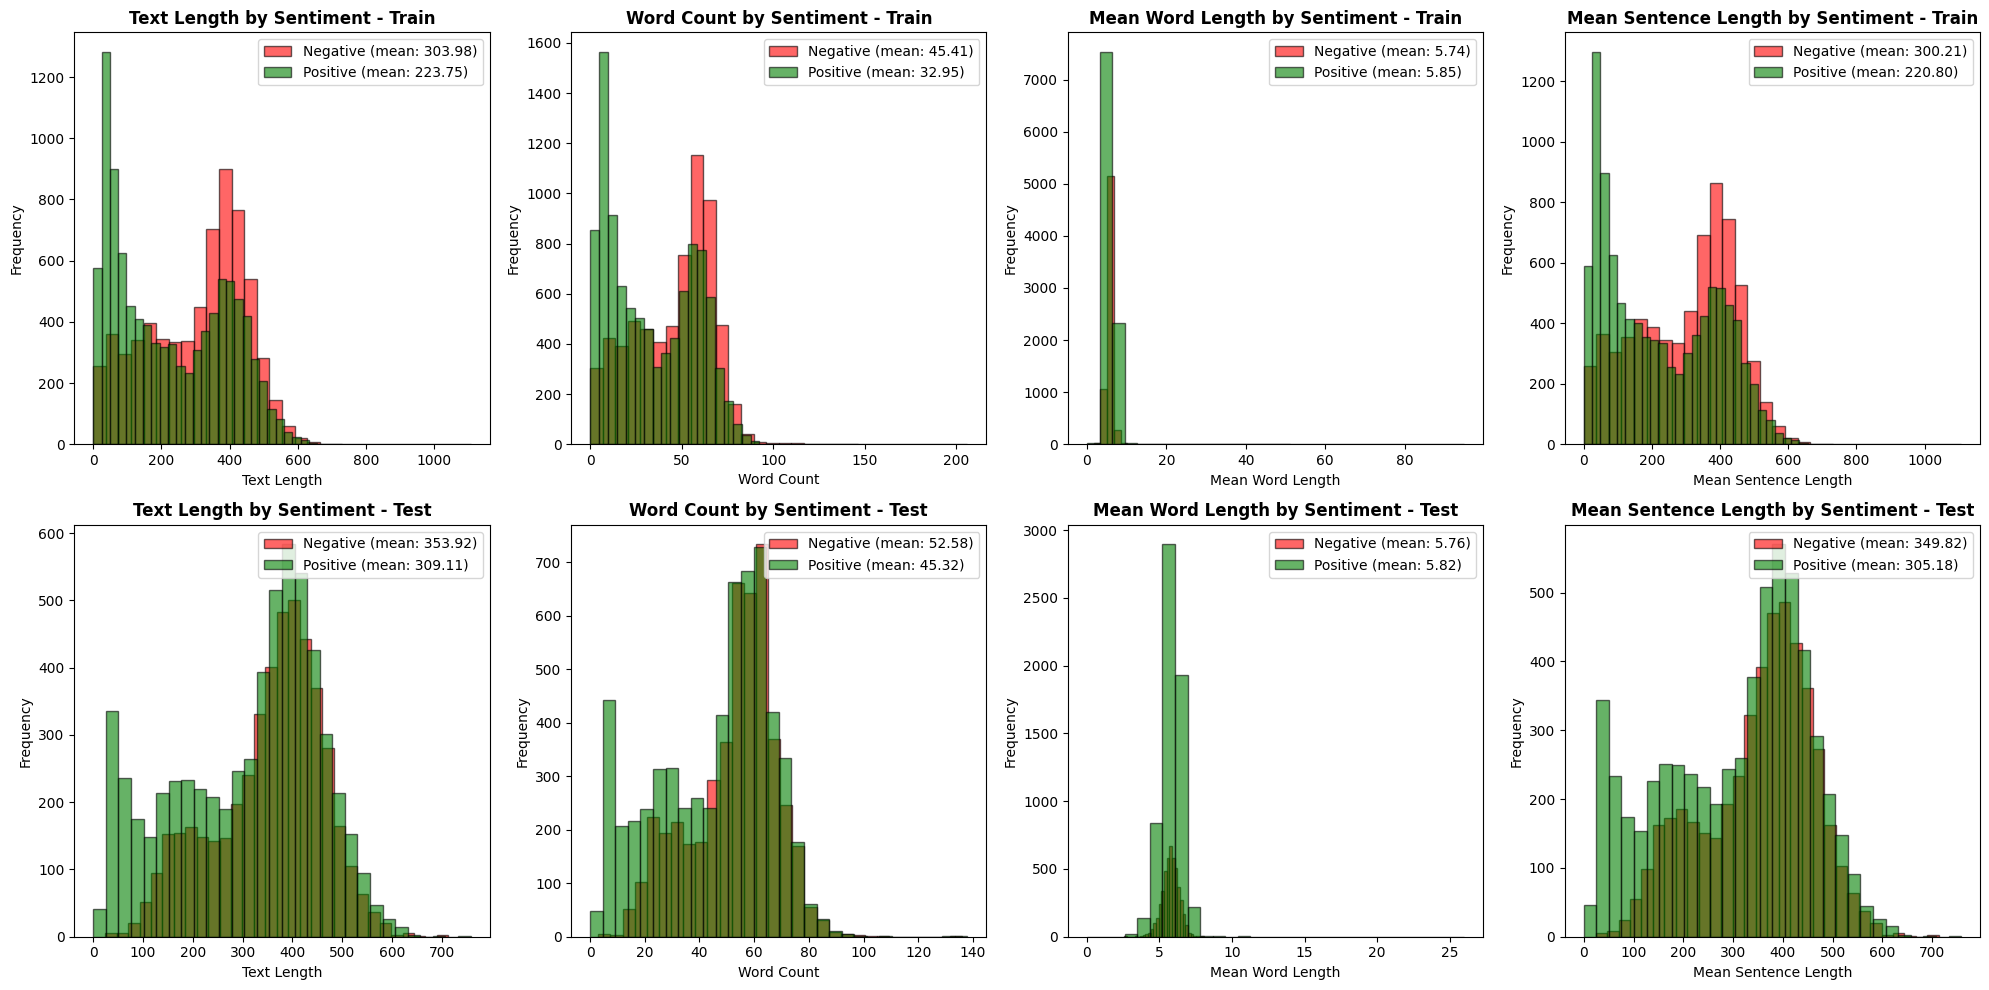

In [65]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

features = ['length', 'word_count', 'mean_word_length', 'mean_sentence_length']
titles = ['Text Length', 'Word Count', 'Mean Word Length', 'Mean Sentence Length']

for idx, (feature, title) in enumerate(zip(features, titles)):
    axes[0, idx].hist(train[feature], bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0, idx].set_title(f'{title} - Train', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel(title)
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].axvline(train[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train[feature].mean():.2f}')
    axes[0, idx].legend()
    
    axes[1, idx].hist(test[feature], bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, idx].set_title(f'{title} - Test', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel(title)
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].axvline(test[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {test[feature].mean():.2f}')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for idx, (feature, title) in enumerate(zip(features, titles)):
    train_pos = train[train['label'] == 1][feature]
    train_neg = train[train['label'] == 0][feature]
    
    axes[0, idx].hist(train_neg, bins=30, alpha=0.6, color='red', label=f'Negative (mean: {train_neg.mean():.2f})', edgecolor='black')
    axes[0, idx].hist(train_pos, bins=30, alpha=0.6, color='green', label=f'Positive (mean: {train_pos.mean():.2f})', edgecolor='black')
    axes[0, idx].set_title(f'{title} by Sentiment - Train', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel(title)
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].legend()
    
    test_pos = test[test['label'] == 1][feature]
    test_neg = test[test['label'] == 0][feature]
    
    axes[1, idx].hist(test_neg, bins=30, alpha=0.6, color='red', label=f'Negative (mean: {test_neg.mean():.2f})', edgecolor='black')
    axes[1, idx].hist(test_pos, bins=30, alpha=0.6, color='green', label=f'Positive (mean: {test_pos.mean():.2f})', edgecolor='black')
    axes[1, idx].set_title(f'{title} by Sentiment - Test', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel(title)
    axes[1, idx].set_ylabel('Frequency')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['printr'] not in stop_words.
  warnings.warn(


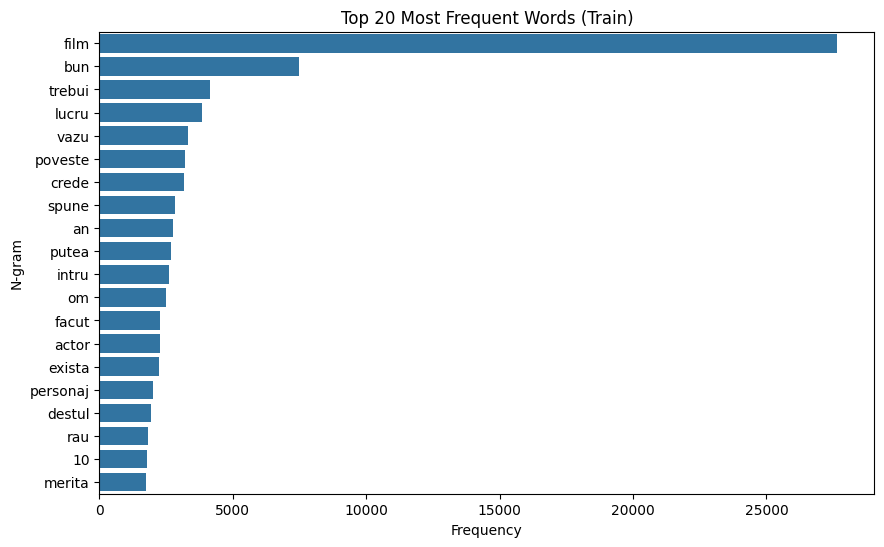

/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['printr'] not in stop_words.
  warnings.warn(


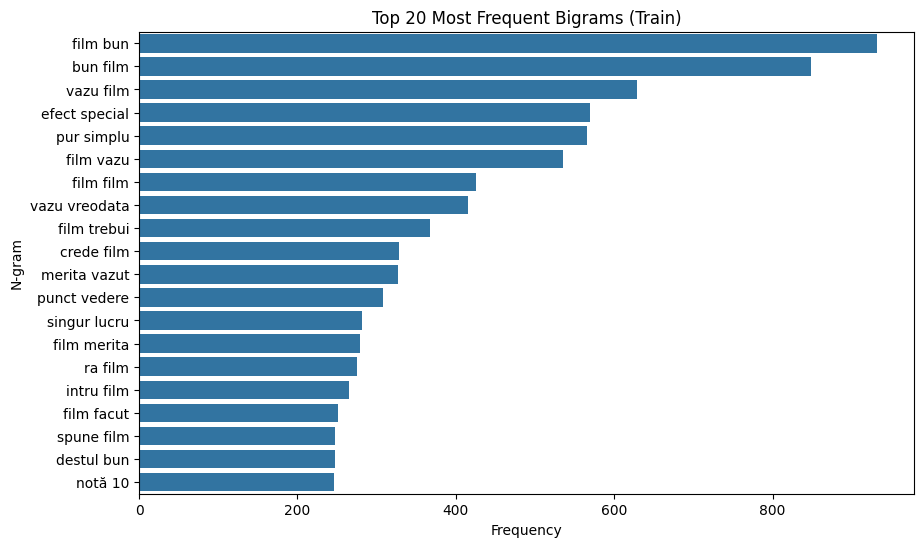

/Users/denis2104/Desktop/Tema 2 IA/.venv/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['printr'] not in stop_words.
  warnings.warn(


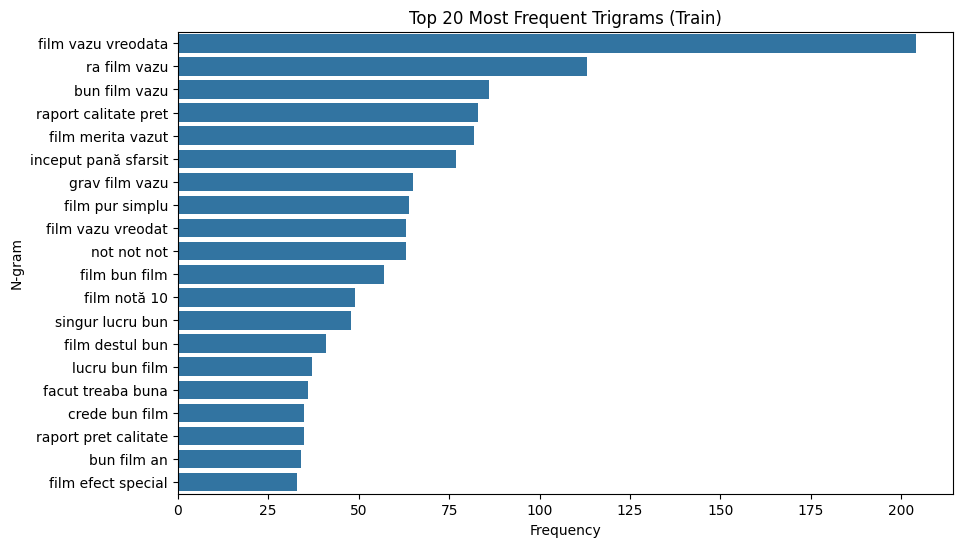

In [66]:
def get_top_ngrams(corpus, n=1, k=20):
    stop_words = nltk.corpus.stopwords.words('romanian')
    
    negation_words = {'nu', 'n', 'nici', 'ba', 'nimic', 'niciodata'}
    stop_words = [w for w in stop_words if w not in negation_words]
    
    stop_words.extend(['br', 'nbsp'])
        
    vec = CountVectorizer(ngram_range=(n, n), stop_words=stop_words).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:k]

def plot_top_ngrams(data, column='text', n=1, title="Top n-grams"):
    corpus = data[column].fillna('').astype(str)
    
    top_ngrams = get_top_ngrams(corpus, n=n)
    
    x, y = map(list, zip(*top_ngrams))
        
    plt.figure(figsize=(10, 6))
    sns.barplot(x=y, y=x)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("N-gram")
    plt.show()

plot_top_ngrams(train, 'text', n=1, title="Top 20 Most Frequent Words (Train)")
plot_top_ngrams(train, 'text', n=2, title="Top 20 Most Frequent Bigrams (Train)")
plot_top_ngrams(train, 'text', n=3, title="Top 20 Most Frequent Trigrams (Train)")

In [67]:
def augment_text_data(text, p_del=0.1, p_swap=0.1):
    if not isinstance(text, str) or len(text.split()) < 3:
        return text
    
    words = text.split()
    
    words_after_del = [w for w in words if random.random() > p_del]
    
    if len(words_after_del) == 0:
        words_after_del = [random.choice(words)]
    
    if len(words_after_del) >= 2 and random.random() < p_swap:
        idx1, idx2 = random.sample(range(len(words_after_del)), 2)
        words_after_del[idx1], words_after_del[idx2] = words_after_del[idx2], words_after_del[idx1]
    
    return " ".join(words_after_del)

In [68]:
all_words = []
for text in train['text']:
    if isinstance(text, str):
        all_words.extend(text.split())

word_counts = Counter(all_words)

vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in word_counts.items():
    if count >= 2:
        vocab[word] = len(vocab)

print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 22354


In [69]:
def text_to_sequence(text, vocab):
    if not isinstance(text, str):
        return []
    return [vocab.get(word, vocab['<UNK>']) for word in text.split()]

def pad_features(sequences, max_len):
    features = np.zeros((len(sequences), max_len), dtype=int)
    for i, row in enumerate(sequences):
        if len(row) > 0:
            features[i, :len(row)] = np.array(row)[:max_len]
    return features

train_sequences = [text_to_sequence(text, vocab) for text in train['text']]
test_sequences = [text_to_sequence(text, vocab) for text in test['text']]

X_train = pad_features(train_sequences, CFG.max_len)
X_test = pad_features(test_sequences, CFG.max_len)

y_train = train['label'].values
y_test = test['label'].values

In [70]:

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Training set size: {len(X_train_split)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 13999
Validation set size: 2471
Test set size: 10786


In [71]:
import io
def load_vectors(fname):
    fin = io.open(fname, 'r', encoding='utf-8', newline='\n', errors='ignore')
    n, d = map(int, fin.readline().split())
    data = {}
    for line in fin:
        tokens = line.rstrip().split(' ')
        data[tokens[0]] = np.asarray(tokens[1:], dtype='float32')
    return data

try:
    fasttext_model = load_vectors(CFG.fasttext_path)
    print(f"FastText model loaded with {len(fasttext_model)} words")
except FileNotFoundError:
    print(f"FastText file not found at {CFG.fasttext_path}")
    print("Please download Romanian FastText vectors from: https://fasttext.cc/docs/en/crawl-vectors.html")
    fasttext_model = None

FastText model loaded with 2000000 words


In [72]:
vocab_size = len(vocab)
weights_matrix = np.zeros((vocab_size, CFG.embedding_dim))
words_found = 0

if fasttext_model is not None:
    for word, i in vocab.items():
        try:
            weights_matrix[i] = fasttext_model[word]
            words_found += 1
        except KeyError:
            weights_matrix[i] = np.random.normal(scale=0.6, size=(CFG.embedding_dim,))
    
    print(f"Succes! Matricea are dimensiunea {weights_matrix.shape}")
    print(f"Vectori FastText gasiti: {words_found} din {len(vocab)}")
else:
    weights_matrix = np.random.normal(scale=0.4, size=(vocab_size, CFG.embedding_dim))
    print("Using random initialization for embedding matrix")

Succes! Matricea are dimensiunea (22354, 300)
Vectori FastText gasiti: 18367 din 22354


In [73]:
train_dataset = TensorDataset(
    torch.LongTensor(X_train_split),
    torch.LongTensor(y_train_split)
)

val_dataset = TensorDataset(
    torch.LongTensor(X_val),
    torch.LongTensor(y_val)
)

test_dataset = TensorDataset(
    torch.LongTensor(X_test),
    torch.LongTensor(y_test)
)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 438
Validation batches: 78
Test batches: 338


In [74]:
class SentimentRNN_Fast(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout, weights_matrix, embedding_dropout=0.3):
        super(SentimentRNN_Fast, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(weights_matrix), 
            freeze=False 
        )
    
        self.embedding_dropout = nn.Dropout(embedding_dropout)
        
        self.rnn = nn.GRU(
            embedding_dim, 
            hidden_dim, 
            num_layers=1, 
            batch_first=True,
            bidirectional=True,
            dropout=0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )
    
    def forward(self, text):
        embedded = self.embedding(text)
        embedded = self.embedding_dropout(embedded)
        
        output, hidden = self.rnn(embedded)
        
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden = self.layer_norm(hidden)
        
        return self.classifier(hidden)

In [75]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, dropout, weights_matrix, embedding_dropout=0.3):
        super(SentimentLSTM, self).__init__()
        
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(weights_matrix), 
            freeze=False
        )
        
        self.embedding_dropout = nn.Dropout(embedding_dropout)
        
        self.lstm = nn.LSTM(
            embedding_dim, 
            hidden_dim, 
            num_layers=n_layers, 
            batch_first=True,
            bidirectional=True,
            dropout=0.3 if n_layers > 1 else 0 
        )
        
        self.layer_norm = nn.LayerNorm(hidden_dim * 4)
        
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )
    
    def forward(self, text):
        embedded = self.embedding(text)
        embedded = self.embedding_dropout(embedded)
        
        output, (hidden, _) = self.lstm(embedded)
        
        avg_pool = torch.mean(output, dim=1)
        max_pool, _ = torch.max(output, dim=1)
        hidden = torch.cat([avg_pool, max_pool], dim=1)
        
        hidden = self.layer_norm(hidden)
        
        return self.classifier(hidden)

In [76]:
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


In [77]:
def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
    
    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [78]:
def test_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)
            
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    accuracy = 100 * correct / total
    return accuracy, all_predictions, all_labels

In [83]:
def train_model(model, train_loader, val_loader, criterion, device, num_epochs, early_stopping_steps, learning_rate, weight_decay=0, max_grad_norm=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2, min_lr=1e-6)
    
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()
        
        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total
        
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_steps:
                print(f"\nEarly stopping at epoch {epoch+1}")
                print(f"Best model from epoch {best_epoch+1}")
                break

    model.load_state_dict(torch.load('best_model.pt'))
    
    train_losses = train_losses[:best_epoch+1]    
    val_accs = val_accs[:best_epoch+1]
    val_losses = val_losses[:best_epoch+1]   
    train_accs = train_accs[:best_epoch+1]
    
    return model, train_losses, val_losses, train_accs, val_accs

In [80]:
def plot_training_curves(train_losses, val_losses, train_accs, val_accs, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(train_losses, label='Train Loss')
    ax1.plot(val_losses, label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{model_name} - Training & Validation Loss')
    ax1.legend()
    
    ax2.plot(train_accs, label='Train Accuracy')
    ax2.plot(val_accs, label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{model_name} - Training & Validation Accuracy')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

In [84]:
CFG.early_stopping_steps = 4
print(f"Early stopping steps set to: {CFG.early_stopping_steps}")

ensemble_configs = [
    {'name': 'base', 'lr': CFG.learning_rate, 'wd': CFG.weight_decay},
    {'name': 'lr_increase', 'lr': CFG.learning_rate * 1.1, 'wd': CFG.weight_decay},
    {'name': 'lr_decrease', 'lr': CFG.learning_rate * 0.9, 'wd': CFG.weight_decay},
    {'name': 'wd_increase', 'lr': CFG.learning_rate, 'wd': CFG.weight_decay * 1.1},
    {'name': 'wd_decrease', 'lr': CFG.learning_rate, 'wd': CFG.weight_decay * 0.9},
]

rnn_ensemble_models = []
lstm_ensemble_models = []
rnn_ensemble_history = []
lstm_ensemble_history = []

print(f"Starting Training for 5-Model Ensemble for both Architectures...")
print(f"Total models to train: {len(ensemble_configs) * 2} (5 RNN + 5 LSTM)")

for i, config in enumerate(ensemble_configs):
    print(f"\n{'='*20} Configuration {i+1}/5: {config['name']} {'='*20}")
    print(f"Learning Rate: {config['lr']:.2e}, Weight Decay: {config['wd']:.2e}")
    
    print(f"\n[Configuration {i+1}] Training RNN Model...")
    model_params_rnn = {
        'vocab_size': len(vocab),
        'embedding_dim': CFG.embedding_dim,
        'hidden_dim': CFG.hidden_dim, 
        'output_dim': CFG.output_dim,
        'dropout': CFG.dropout,
        'weights_matrix': weights_matrix,
        'embedding_dropout': CFG.embedding_dropout
    }
    
    rnn_model_variant = SentimentRNN_Fast(**model_params_rnn).to(CFG.device)
    
    rnn_model_variant, r_t_loss, r_v_loss, r_t_acc, r_v_acc = train_model(
        rnn_model_variant, train_loader, val_loader, CFG.criterion, CFG.device,
        CFG.num_epochs, CFG.early_stopping_steps, 
        learning_rate=config['lr'],
        weight_decay=config['wd'], 
        max_grad_norm=CFG.max_grad_norm
    )
    
    rnn_save_name = f'rnn_ensemble_{i+1}.pt'
    torch.save(rnn_model_variant.state_dict(), rnn_save_name)
    rnn_ensemble_models.append(rnn_model_variant)
    rnn_ensemble_history.append({
        'config': config['name'],
        'train_loss': r_t_loss, 'val_loss': r_v_loss,
        'train_acc': r_t_acc, 'val_acc': r_v_acc
    })
    print(f"Saved RNN model to {rnn_save_name}")

    print(f"\n[Configuration {i+1}] Training LSTM Model...")
    model_params_lstm = {
        'vocab_size': len(vocab),
        'embedding_dim': CFG.embedding_dim,
        'hidden_dim': 128,              
        'output_dim': CFG.output_dim,
        'n_layers': 2,                  
        'dropout': CFG.dropout,
        'weights_matrix': weights_matrix,
        'embedding_dropout': CFG.embedding_dropout
    }
    
    lstm_model_variant = SentimentLSTM(**model_params_lstm).to(CFG.device)
    
    lstm_model_variant, l_t_loss, l_v_loss, l_t_acc, l_v_acc = train_model(
        lstm_model_variant, train_loader, val_loader, CFG.criterion, CFG.device,
        CFG.num_epochs, CFG.early_stopping_steps,
        learning_rate=config['lr'],
        weight_decay=config['wd'],
        max_grad_norm=CFG.max_grad_norm
    )
    
    lstm_save_name = f'lstm_ensemble_{i+1}.pt'
    torch.save(lstm_model_variant.state_dict(), lstm_save_name)
    lstm_ensemble_models.append(lstm_model_variant)
    lstm_ensemble_history.append({
        'config': config['name'],
        'train_loss': l_t_loss, 'val_loss': l_v_loss,
        'train_acc': l_t_acc, 'val_acc': l_v_acc
    })
    print(f"Saved LSTM model to {lstm_save_name}")

print("\nAll ensemble models trained and saved.")

Early stopping steps set to: 4
Starting Training for 5-Model Ensemble for both Architectures...
Total models to train: 10 (5 RNN + 5 LSTM)

==================== Configuration 1/5: base ====================
Learning Rate: 1.00e-04, Weight Decay: 5.00e-04

[Configuration 1] Training RNN Model...
Epoch 1/20
  Train Loss: 0.7020, Train Acc: 56.47%
  Val Loss: 0.6679, Val Acc: 60.30%
Epoch 2/20
  Train Loss: 0.6689, Train Acc: 59.56%
  Val Loss: 0.6367, Val Acc: 64.43%
Epoch 3/20
  Train Loss: 0.6424, Train Acc: 63.79%
  Val Loss: 0.6104, Val Acc: 71.43%
Epoch 4/20
  Train Loss: 0.5845, Train Acc: 73.11%
  Val Loss: 0.5278, Val Acc: 77.38%
Epoch 5/20
  Train Loss: 0.5043, Train Acc: 81.13%
  Val Loss: 0.4840, Val Acc: 81.51%
Epoch 6/20
  Train Loss: 0.4601, Train Acc: 84.78%
  Val Loss: 0.4597, Val Acc: 83.77%
Epoch 7/20
  Train Loss: 0.4260, Train Acc: 87.34%
  Val Loss: 0.4676, Val Acc: 84.06%
Epoch 8/20
  Train Loss: 0.4018, Train Acc: 88.76%
  Val Loss: 0.4603, Val Acc: 84.34%
Epoch 9/2

Plotting RNN Ensemble History:


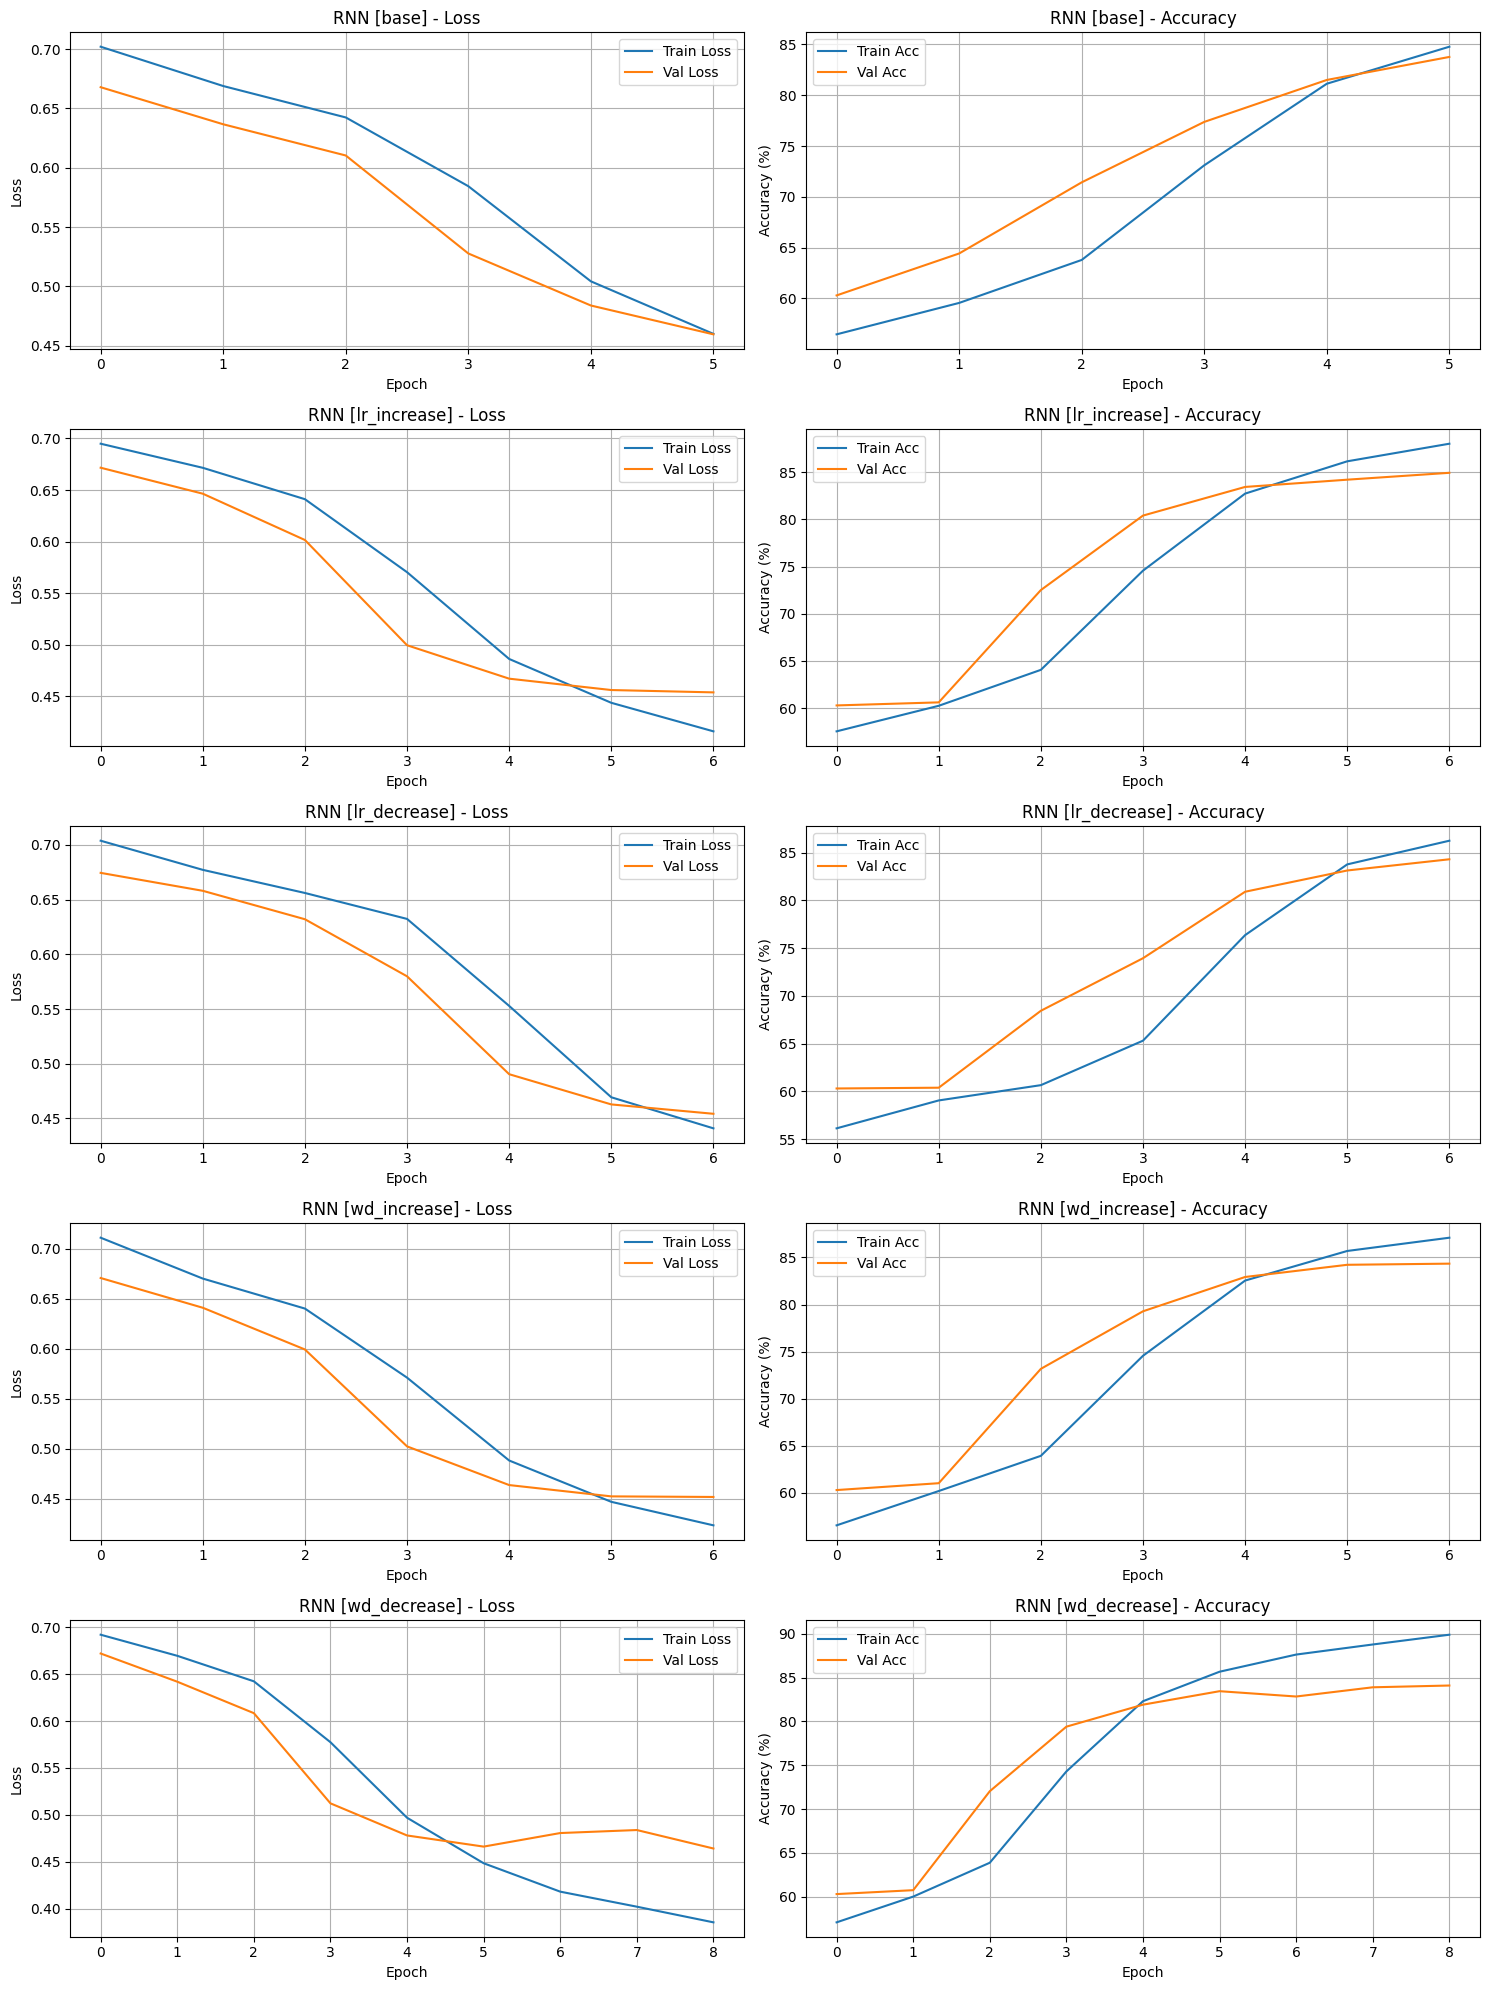


Plotting LSTM Ensemble History:


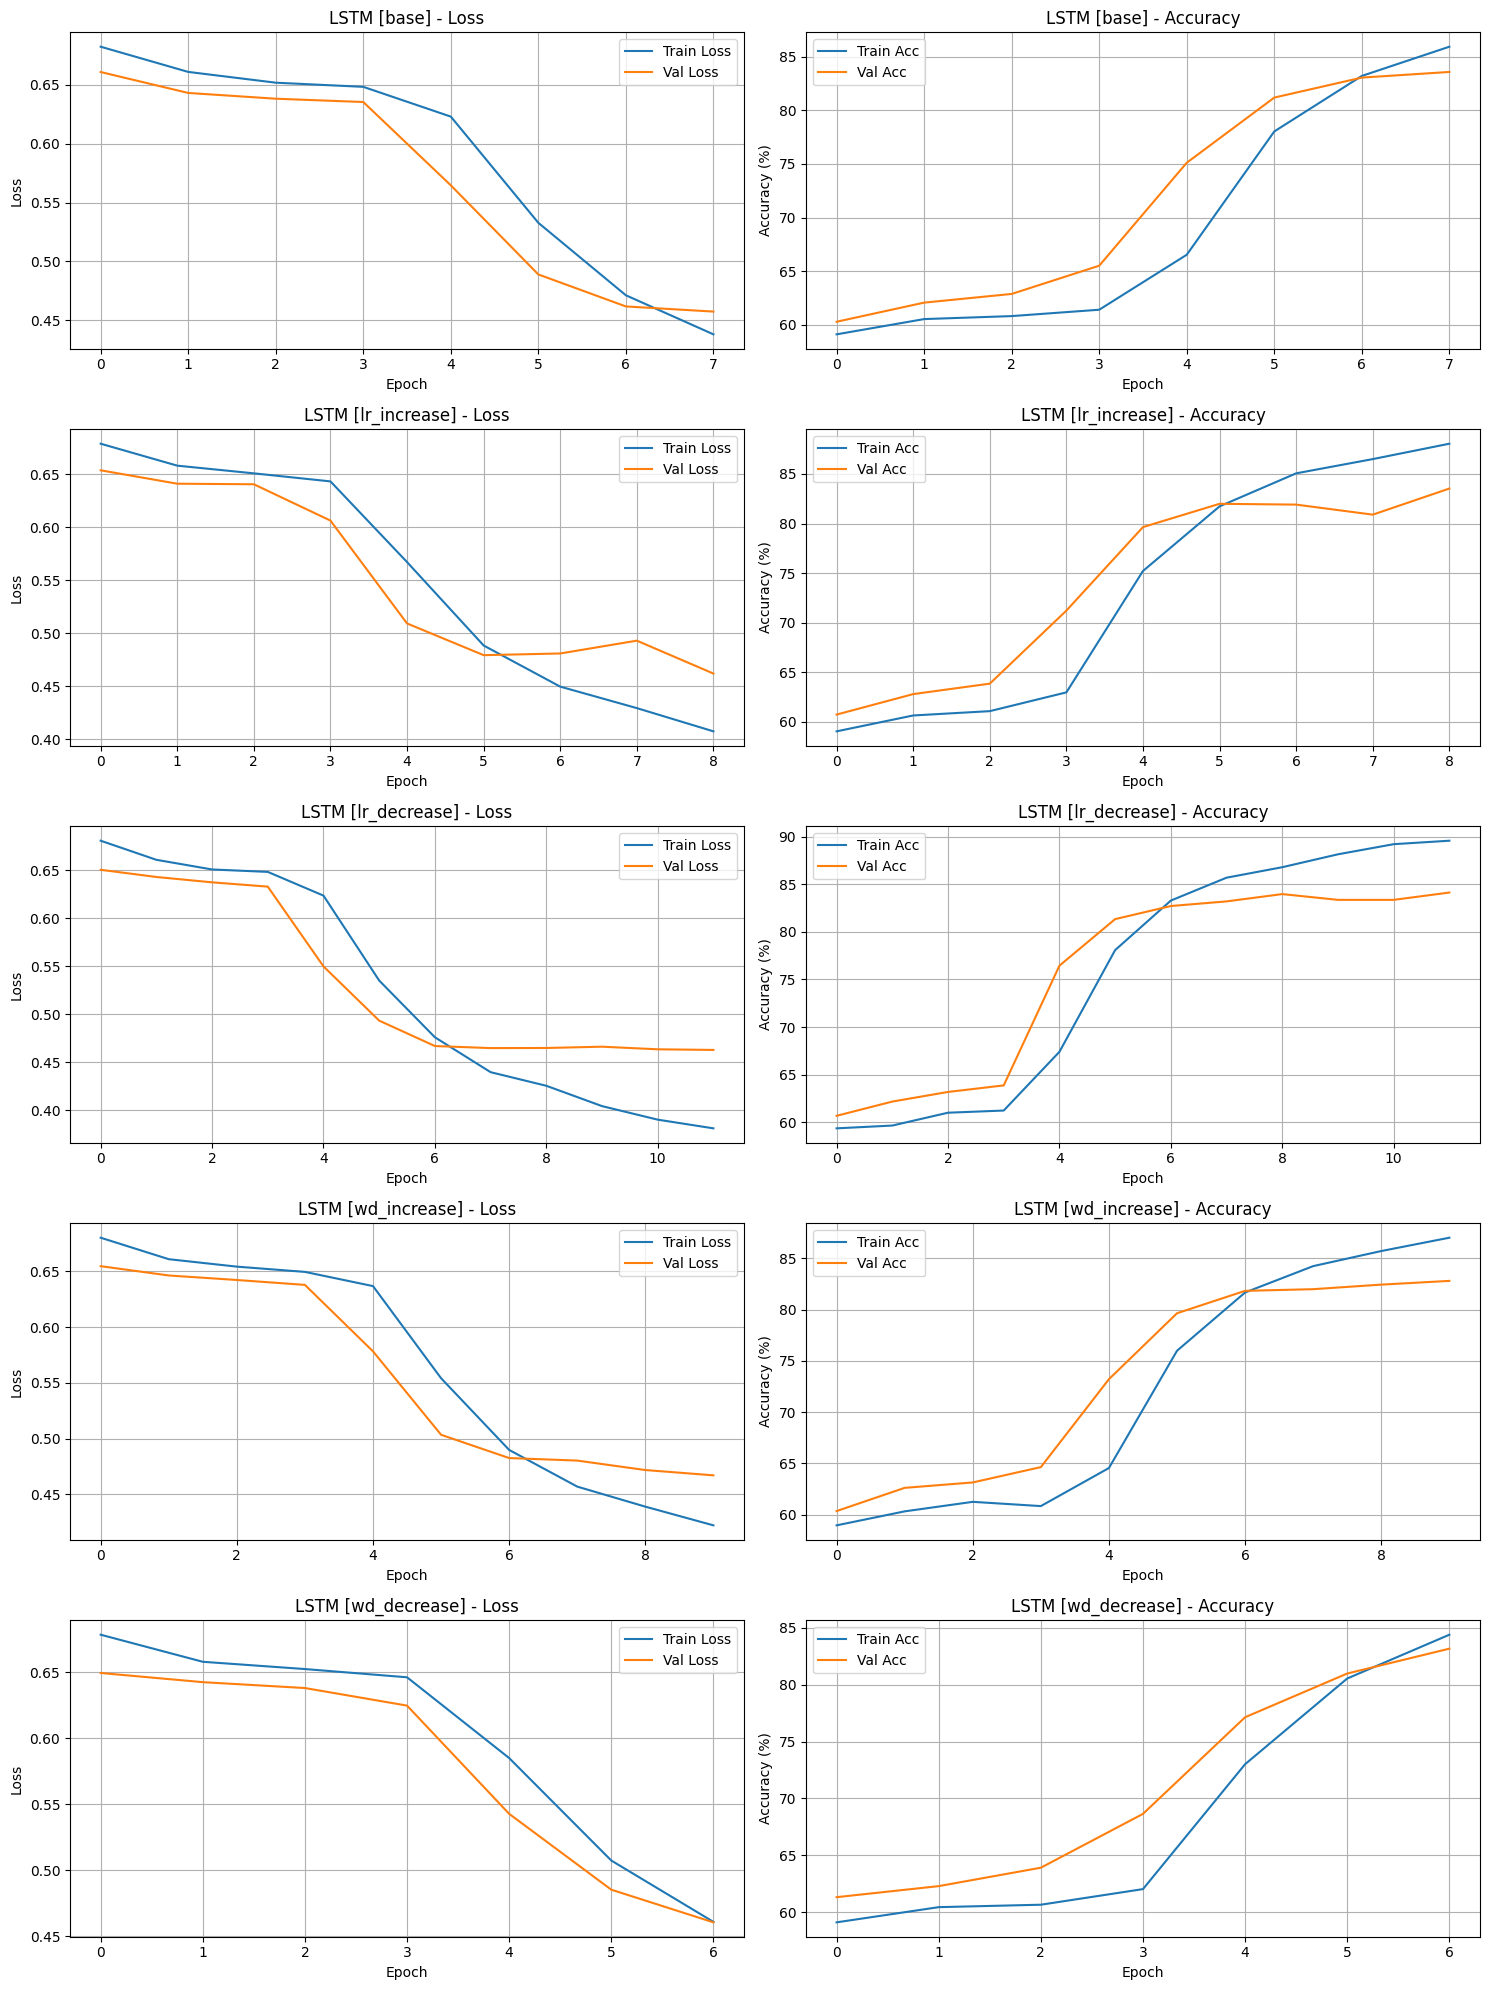

In [85]:
def plot_ensemble_history(history_list, model_type_name="Model"):
    num_configs = len(history_list)
    fig, axes = plt.subplots(num_configs, 2, figsize=(15, 4 * num_configs))
    
    if num_configs == 1:
        axes = np.array([axes]) 

    for i, history in enumerate(history_list):
        config_name = history['config']
        
        ax_loss = axes[i][0]
        ax_loss.plot(history['train_loss'], label='Train Loss')
        ax_loss.plot(history['val_loss'], label='Val Loss')
        ax_loss.set_title(f"{model_type_name} [{config_name}] - Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()
        ax_loss.grid(True)
        
        ax_acc = axes[i][1]
        ax_acc.plot(history['train_acc'], label='Train Acc')
        ax_acc.plot(history['val_acc'], label='Val Acc')
        ax_acc.set_title(f"{model_type_name} [{config_name}] - Accuracy")
        ax_acc.set_xlabel("Epoch")
        ax_acc.set_ylabel("Accuracy (%)")
        ax_acc.legend()
        ax_acc.grid(True)

    plt.tight_layout()
    plt.show()

print("Plotting RNN Ensemble History:")
plot_ensemble_history(rnn_ensemble_history, "RNN")

print("\nPlotting LSTM Ensemble History:")
plot_ensemble_history(lstm_ensemble_history, "LSTM")

In [86]:
def predict_ensemble(models, data_loader, device):
    for model in models:
        model.eval()
        
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_probs = []
            for model in models:
                outputs = model(batch_x)
                probs = torch.softmax(outputs, dim=1)
                batch_probs.append(probs)
            
            stacked_probs = torch.stack(batch_probs)
            avg_probs = torch.mean(stacked_probs, dim=0)
            
            _, predicted = torch.max(avg_probs, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
            
    correct = sum(p == l for p, l in zip(all_predictions, all_labels))
    accuracy = 100 * correct / len(all_labels)
    
    return accuracy, all_predictions, all_labels

In [87]:
def see_1_to_k_ensemble_models(models, data_loader, device):
    return predict_ensemble(models, data_loader, device)

In [88]:
print("Evaluating RNN Ensemble...")
for k in range(1, len(rnn_ensemble_models) + 1):
    ens_acc, ens_preds, ens_labels = see_1_to_k_ensemble_models(rnn_ensemble_models[:k], test_loader, CFG.device)
    print(f"RNN Ensemble with {k} models - Test Accuracy: {ens_acc:.2f}%")  

print("Evaluating LSTM Ensemble...")
for k in range(1, len(lstm_ensemble_models) + 1):
    ens_acc, ens_preds, ens_labels = see_1_to_k_ensemble_models(lstm_ensemble_models[:k], test_loader, CFG.device)
    print(f"LSTM Ensemble with {k} models - Test Accuracy: {ens_acc:.2f}%")

Evaluating RNN Ensemble...
RNN Ensemble with 1 models - Test Accuracy: 82.32%
RNN Ensemble with 2 models - Test Accuracy: 83.39%
RNN Ensemble with 3 models - Test Accuracy: 83.71%
RNN Ensemble with 4 models - Test Accuracy: 84.03%
RNN Ensemble with 5 models - Test Accuracy: 83.91%
Evaluating LSTM Ensemble...
LSTM Ensemble with 1 models - Test Accuracy: 83.54%
LSTM Ensemble with 2 models - Test Accuracy: 83.69%
LSTM Ensemble with 3 models - Test Accuracy: 83.85%
LSTM Ensemble with 4 models - Test Accuracy: 83.65%
LSTM Ensemble with 5 models - Test Accuracy: 83.59%


Generating Confusion Matrix for RNN Ensemble (4 models)...


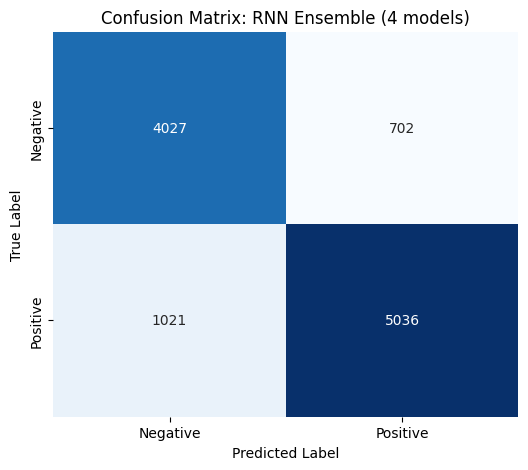

Generating Confusion Matrix for LSTM Ensemble (3 models)...


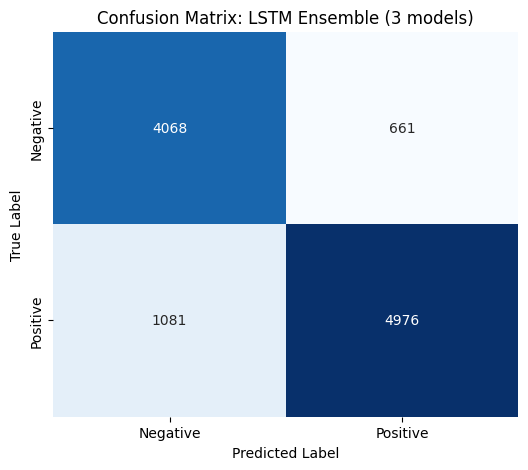

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_custom_confusion_matrix(models_list, k, model_name, loader, device):
    _, preds, labels = see_1_to_k_ensemble_models(models_list[:k], loader, device)
    
    # Compute Confusion Matrix
    cm = confusion_matrix(labels, preds)
    
    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix: {model_name} Ensemble ({k} models)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# 1. RNN Ensemble with 4 models
print("Generating Confusion Matrix for RNN Ensemble (4 models)...")
plot_custom_confusion_matrix(rnn_ensemble_models, 4, "RNN", test_loader, CFG.device)

# 2. LSTM Ensemble with 3 models
print("Generating Confusion Matrix for LSTM Ensemble (3 models)...")
plot_custom_confusion_matrix(lstm_ensemble_models, 3, "LSTM", test_loader, CFG.device)